# Two-scenario Dyad vs Solo Experiment with Mastery Comparison

We compare:
- **Scenario 1 (Solo):** Learner continues self-regulated practice.
- **Scenario 2 (Dyad):** Learners practice in dyads with role-based updates (performer vs. coach).

We also compute and compare *mastery* (average performance across the last 10 episodes).

Mastery (Solo->Solo): 6.390000000000001
Mastery (Solo->Dyad): 6.609999999999999


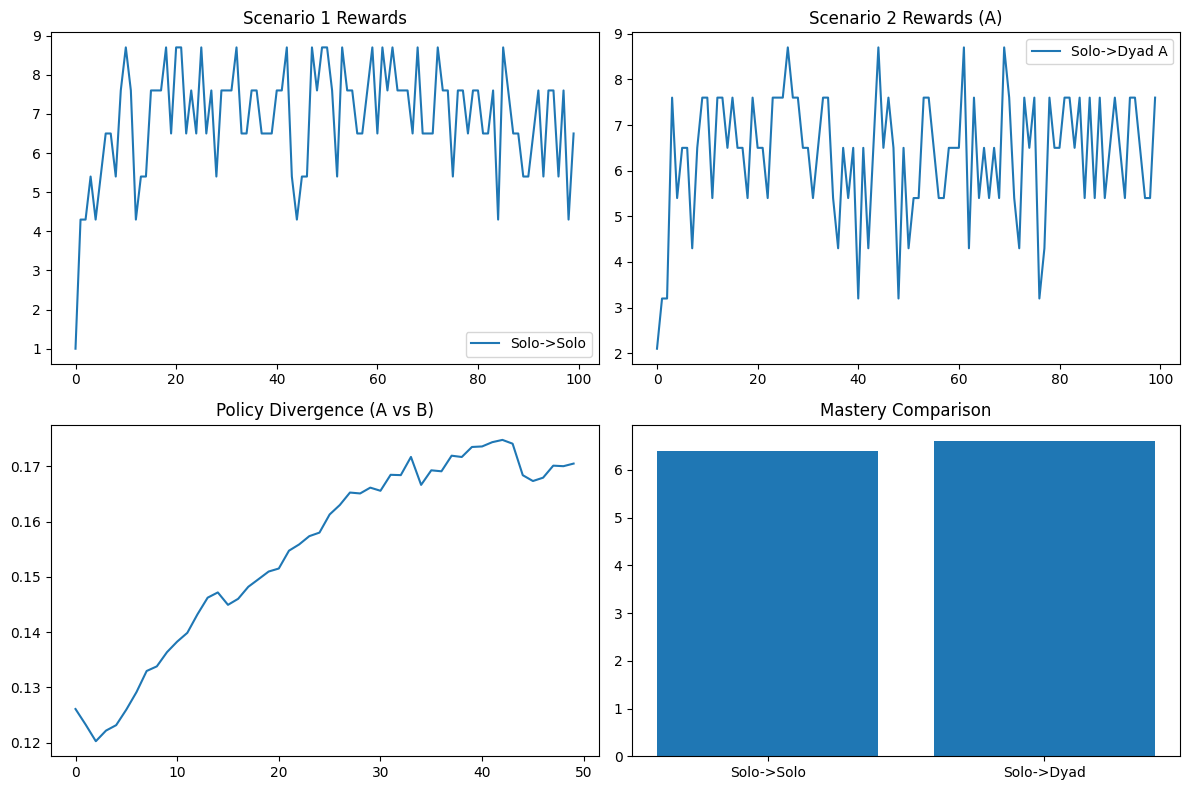

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

class PianoEnv:
    def __init__(self, n_states=10, n_actions=5, restrict_ratio=0.7):
        self.n_states = n_states
        self.n_actions = n_actions
        self.restrict_ratio = restrict_ratio
        self.state = 0
    def reset(self):
        self.state = 0
        return self.state
    def step(self, action):
        reward = 1.0 if action == (self.state % self.n_actions) else -0.1
        self.state = (self.state + 1) % self.n_states
        done = (self.state == 0)
        return self.state, reward, done, {}
    def allowed_actions(self, state):
        k = max(1, int(self.restrict_ratio * self.n_actions))
        rng = np.random.RandomState(state)
        return list(rng.choice(self.n_actions, size=k, replace=False))

class Talent:
    def __init__(self, gamma=0.95, base_lr=0.1):
        self.gamma = gamma
        self.base_lr = base_lr

class QLearningAgent:
    def __init__(self, talent: Talent, n_states: int, n_actions: int, eps=0.2):
        self.talent = talent
        self.n_states = n_states
        self.n_actions = n_actions
        self.Q = np.zeros((n_states, n_actions))
        self.eps = eps
    def start_episode(self):
        pass
    def alpha(self):
        return self.talent.base_lr
    def act(self, state, allowed):
        if np.random.rand() < self.eps:
            return random.choice(allowed)
        q_vals = [self.Q[state, a] for a in allowed]
        return allowed[int(np.argmax(q_vals))]
    def generate_action(self, state, allowed):
        q_vals = [self.Q[state, a] for a in allowed]
        return allowed[int(np.argmax(q_vals))]
    def update_role_based(self, s, a, r, s_next, done, role="performer", obs_factor=0.3):
        alpha = self.alpha() if role=="performer" else obs_factor * self.alpha()
        target = r + (0 if done else self.talent.gamma * np.max(self.Q[s_next]))
        self.Q[s,a] += alpha * (target - self.Q[s,a])

class DyadConfig:
    def __init__(self, obs_factor=0.3, swap_every_step=True, coach_update_uses_own_action=True):
        self.obs_factor = obs_factor
        self.swap_every_step = swap_every_step
        self.coach_update_uses_own_action = coach_update_uses_own_action

def run_solo(env, agent, n_episodes, seed=0):
    rng = random.Random(seed)
    rewards, steps = [], []
    for ep in range(n_episodes):
        agent.start_episode()
        s = env.reset()
        done, total_r, step_count = False, 0.0, 0
        while not done:
            step_count += 1
            allowed = env.allowed_actions(s)
            a = agent.act(s, allowed)
            s_next, r, done, _ = env.step(a)
            agent.update_role_based(s, a, r, s_next, done, role="performer")
            total_r += r
            s = s_next
        rewards.append(total_r)
        steps.append(step_count)
    return np.array(rewards), np.array(steps)

def run_dyad(env, a, b, n_episodes, cfg, seed=0):
    rng = random.Random(seed)
    rewards, steps, divergence, action_agreement = [], [], [], []
    for ep in range(n_episodes):
        a.start_episode(); b.start_episode()
        s = env.reset(); done, total_r, step_count = False, 0.0, 0
        performer_first_is_a = (ep % 2 == 0)
        performer, coach = (a,b) if performer_first_is_a else (b,a)
        while not done:
            step_count += 1
            allowed = env.allowed_actions(s)
            action = performer.act(s, allowed)
            coach_action = coach.generate_action(s, allowed)
            s_next, r, done, _ = env.step(action)
            performer.update_role_based(s, action, r, s_next, done, role="performer")
            if cfg.coach_update_uses_own_action:
                coach.update_role_based(s, coach_action, r, s_next, done, role="coach", obs_factor=cfg.obs_factor)
            else:
                coach.update_role_based(s, action, r, s_next, done, role="coach", obs_factor=cfg.obs_factor)
            total_r += r
            action_agreement.append(1 if action==coach_action else 0)
            s = s_next
            if cfg.swap_every_step:
                performer, coach = coach, performer
        rewards.append(total_r); steps.append(step_count)
        flat_a, flat_b = a.Q.flatten(), b.Q.flatten()
        denom = (np.linalg.norm(flat_a)*np.linalg.norm(flat_b)+1e-12)
        cos_sim = float(np.dot(flat_a, flat_b)/denom)
        divergence.append(1.0-cos_sim)
    return {"rewards":np.array(rewards), "steps":np.array(steps), "divergence":np.array(divergence), "agreement":np.array(action_agreement)}

# Experiment parameters
env = PianoEnv(n_states=12, n_actions=6, restrict_ratio=0.7)
talentA = Talent(gamma=0.95, base_lr=0.1)
talentB = Talent(gamma=0.90, base_lr=0.05)
episodes_phase1, episodes_phase2 = 50, 50

# Scenario 1: Solo -> Solo
agent_solo = QLearningAgent(talentA, env.n_states, env.n_actions)
r1_p1, _ = run_solo(env, agent_solo, episodes_phase1)
r1_p2, _ = run_solo(env, agent_solo, episodes_phase2)

# Scenario 2: Solo -> Dyad
agentA = QLearningAgent(talentA, env.n_states, env.n_actions)
agentB = QLearningAgent(talentB, env.n_states, env.n_actions)
r2_p1a, _ = run_solo(env, agentA, episodes_phase1)
r2_p1b, _ = run_solo(env, agentB, episodes_phase1)
cfg = DyadConfig(obs_factor=0.3, swap_every_step=True, coach_update_uses_own_action=True)
res_dyad = run_dyad(env, agentA, agentB, episodes_phase2, cfg)

# --- Mastery Comparison ---
def compute_mastery(rewards, window=10):
    return np.mean(rewards[-window:])

mastery_solo = compute_mastery(r1_p2)
mastery_dyad = compute_mastery(res_dyad['rewards'])
print('Mastery (Solo->Solo):', mastery_solo)
print('Mastery (Solo->Dyad):', mastery_dyad)

# Plot results
plt.figure(figsize=(12,8))
plt.subplot(2,2,1); plt.plot(np.arange(len(r1_p1)+len(r1_p2)), np.concatenate([r1_p1,r1_p2]), label='Solo->Solo'); plt.legend(); plt.title('Scenario 1 Rewards')
plt.subplot(2,2,2); plt.plot(np.arange(len(r2_p1a)+len(res_dyad['rewards'])), np.concatenate([r2_p1a,res_dyad['rewards']]), label='Solo->Dyad A'); plt.legend(); plt.title('Scenario 2 Rewards (A)')
plt.subplot(2,2,3); plt.plot(res_dyad['divergence']); plt.title('Policy Divergence (A vs B)')
plt.subplot(2,2,4); plt.bar(['Solo->Solo','Solo->Dyad'], [mastery_solo, mastery_dyad]); plt.title('Mastery Comparison')
plt.tight_layout(); plt.show()
